[2026-07-16 16:16:12] [info     ] 开始计算复合因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-16 16:16:13] [info     ] 训练集：2023-01-01 ~ 2023-12-31
[2026-07-16 16:16:13] [info     ] SQL特征计算...
[2026-07-16 16:24:37] [info     ] 测试集：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-16 16:24:37] [info     ] SQL特征计算...
[2026-07-16 16:24:53] [info     ] 因子完成，输出 242000 行，共242个交易日
[2026-07-16 16:24:53] [info     ] 加载因子库用于评测
[2026-07-16 16:24:54] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-16 16:24:56] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-16 16:24:57] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-16 16:24:58] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-16 16:24:58] [info     ] ========== 数据检查 ==========
[2026-07-16 16:24:58] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 

时段,IC
2024-01-15~2024-02-08,-0.0096
2024-09-24~2024-10-08,0.0191

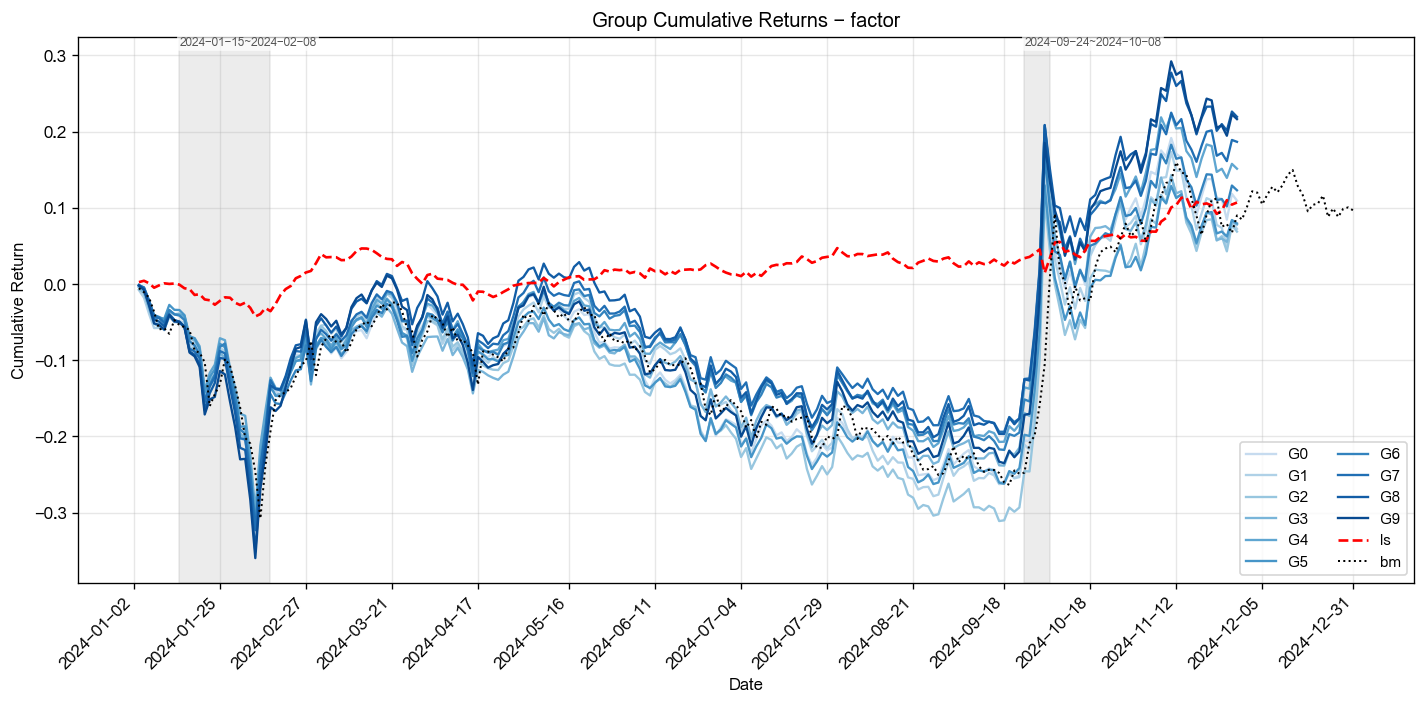
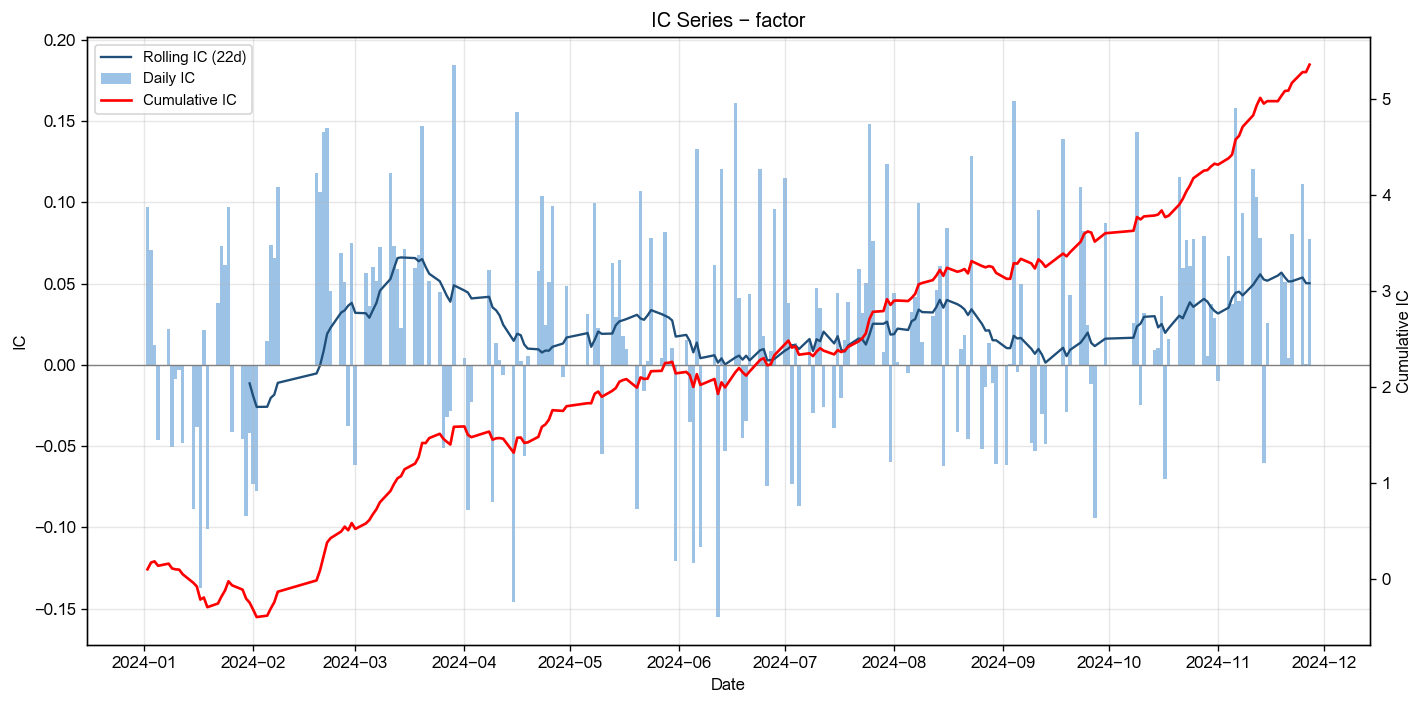
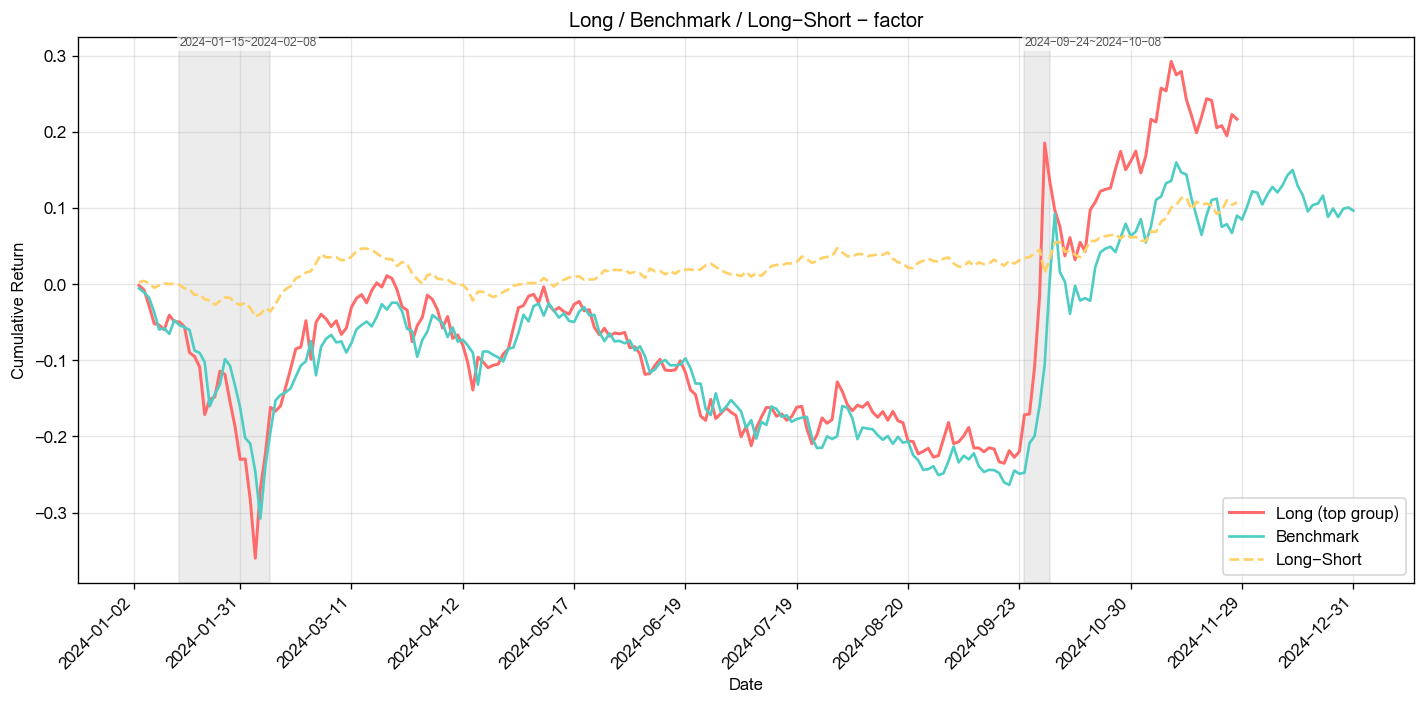
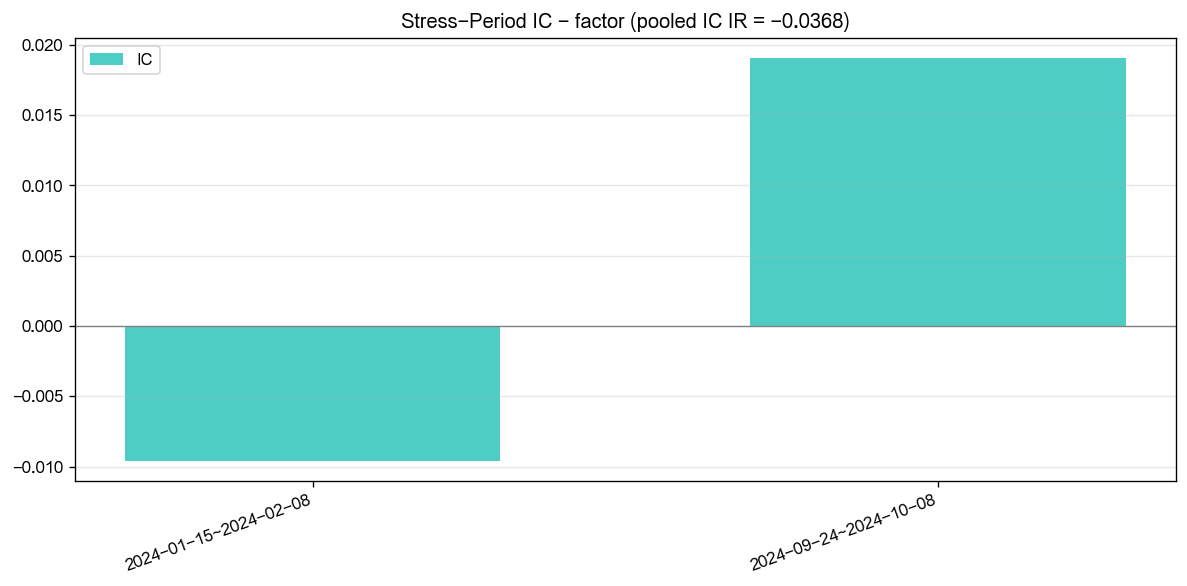
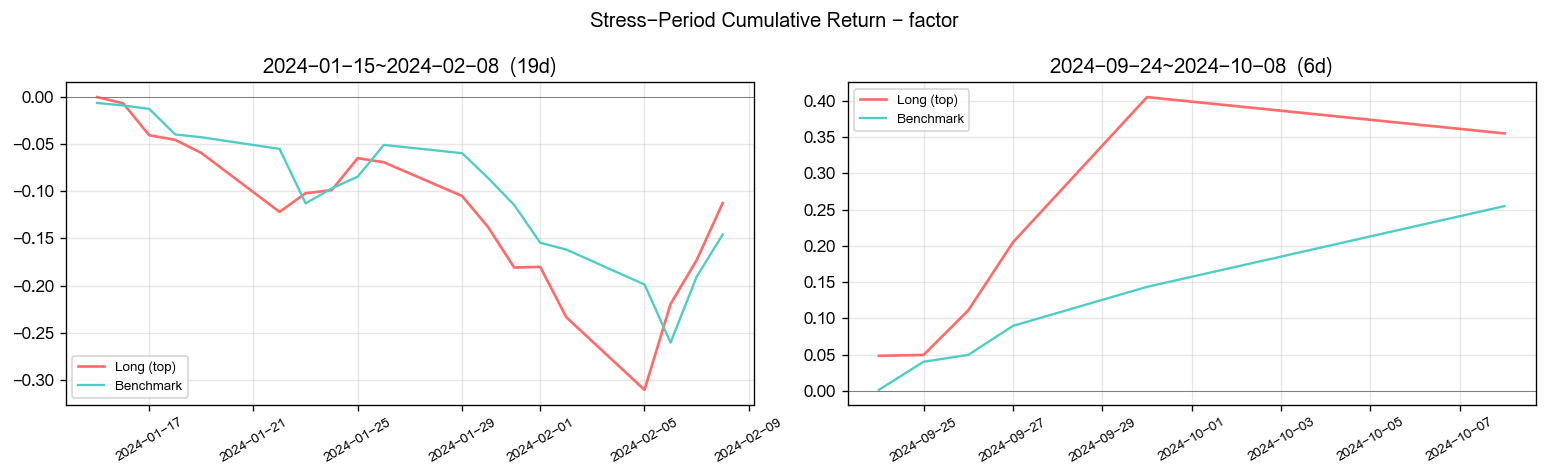

[2026-07-16 16:25:45] [info     ] ========== 因子池回归 ==========
[2026-07-16 16:25:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-16 16:25:49] [info     ] 获取收益率数据, 耗时: 3.8238 秒
[2026-07-16 16:25:50] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.5232 秒
[2026-07-16 16:25:50] [info     ] 统计 回归结果, 耗时: 0.0068 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9361,0.0447,0.0231,1.0000
2,amount,1.7057,0.0186,0.0109,0.9000
3,netflow_amount_rate_main,1.5829,0.0101,0.0064,1.0000
4,gross_profit_rate_ttm,1.5359,0.0070,0.0046,1.0000
5,netflow_amount_main,1.5071,0.0252,0.0167,1.0000
6,net_profit_rate_ttm,1.4516,0.0040,0.0028,0.8000
7,pb,1.4162,0.0097,0.0068,1.0000
8,bias_20,1.4064,0.0302,0.0215,0.9000
9,cci_14,1.3881,0.0339,0.0244,1.0000
10,ps_ttm,1.3291,0.0037,0.0028,0.9000

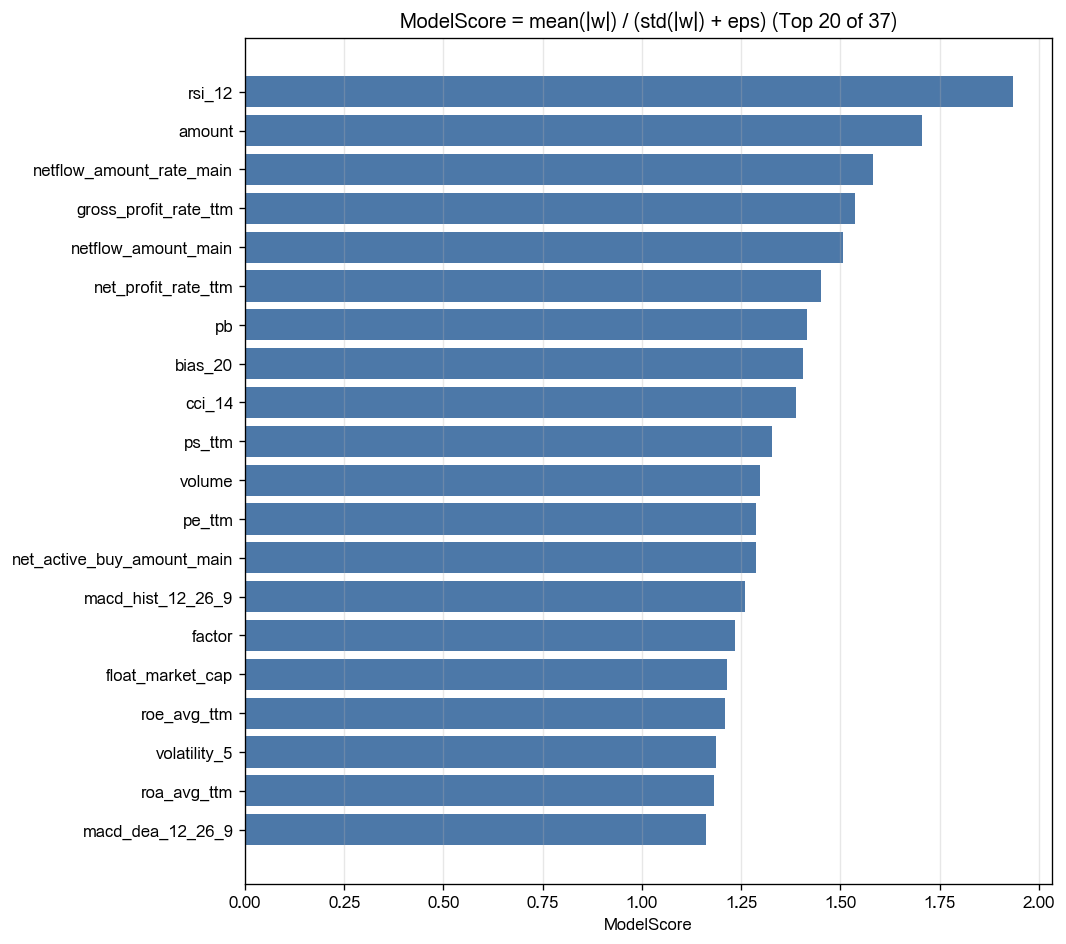
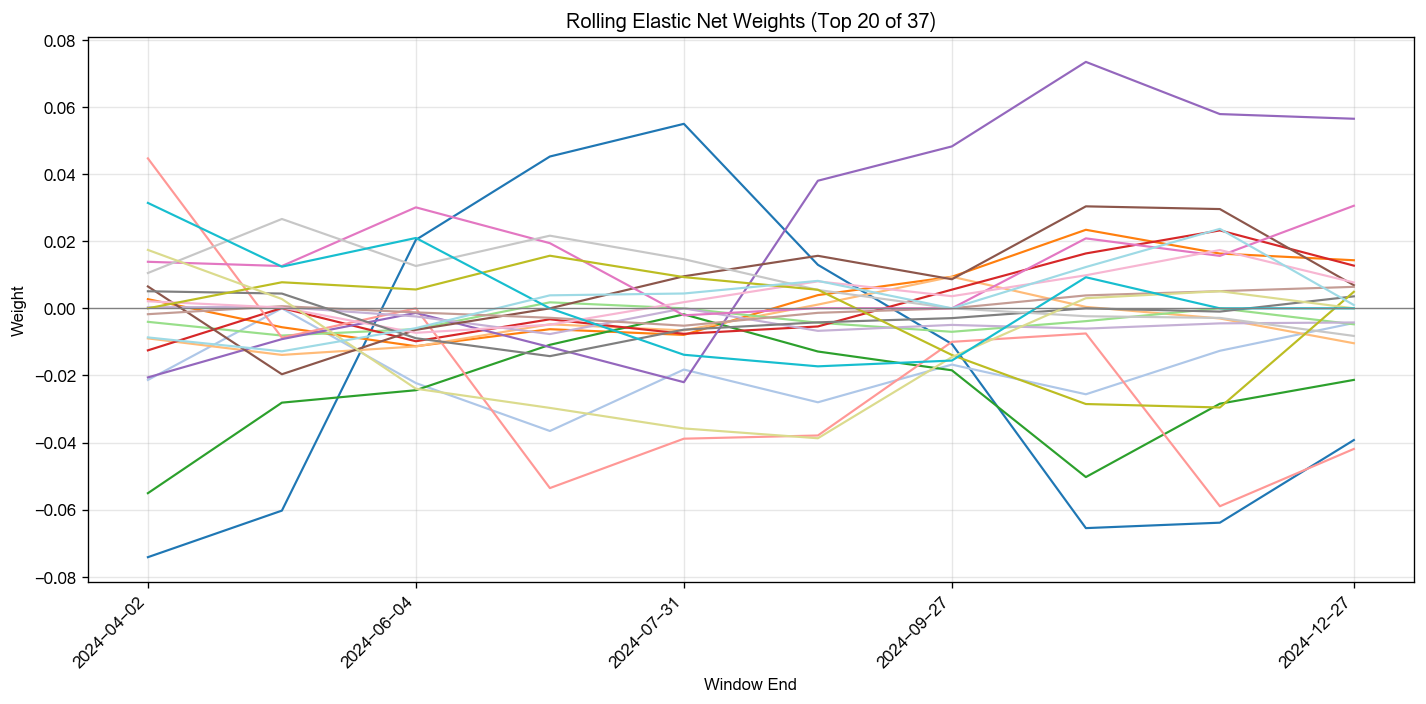
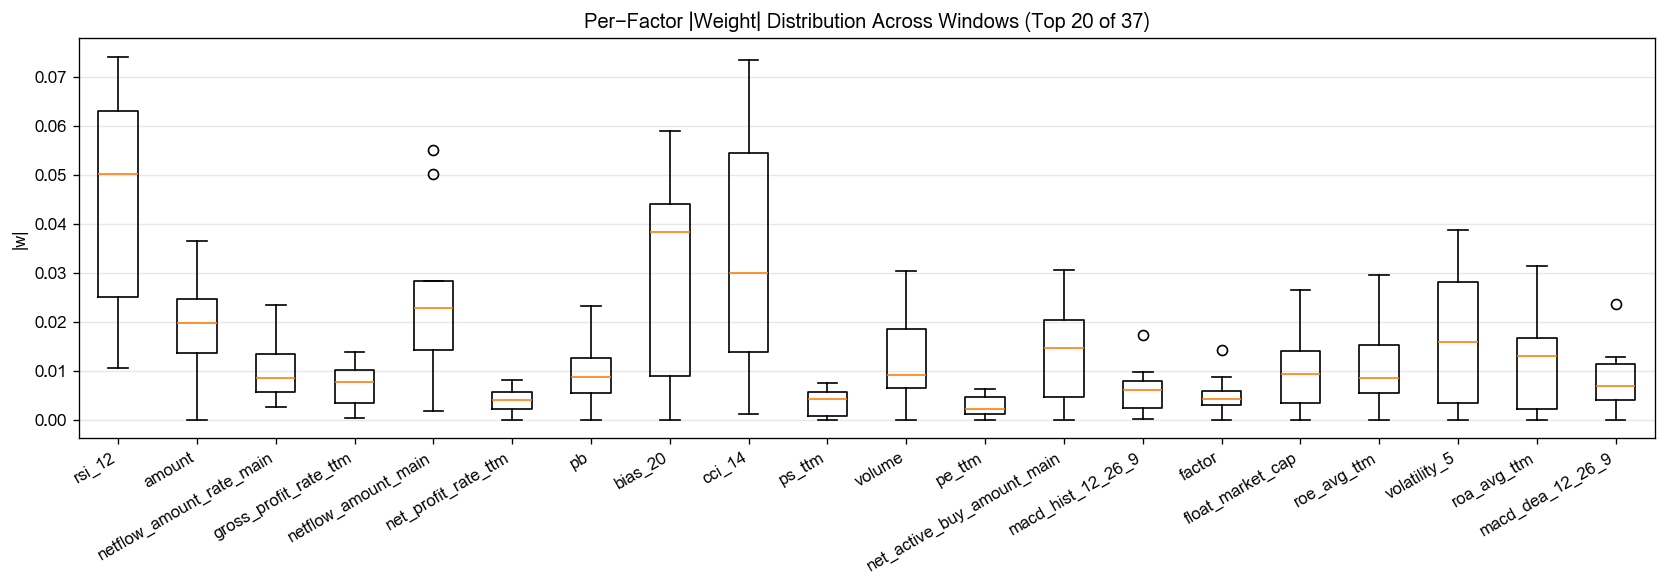
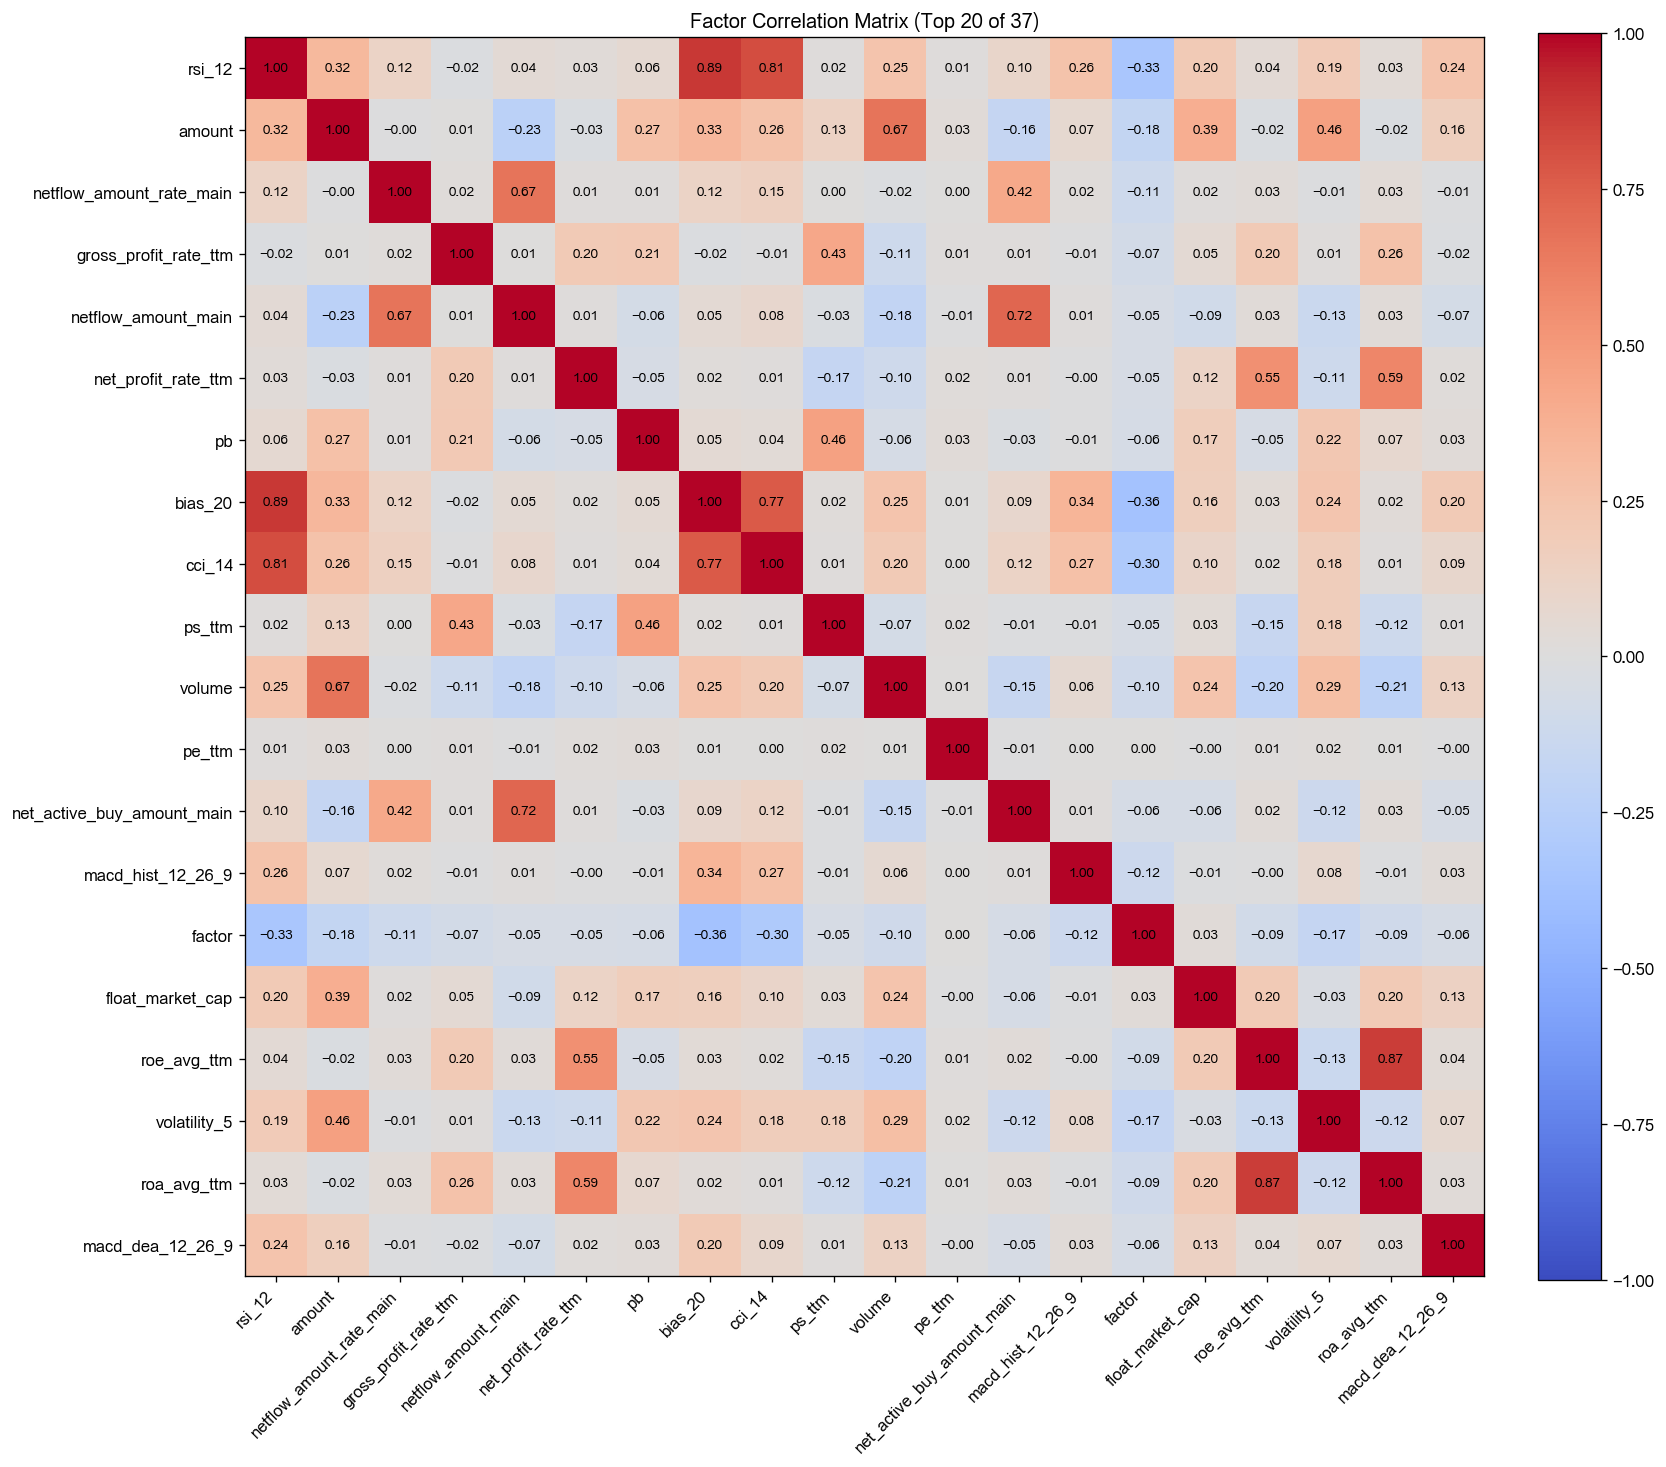

[2026-07-16 16:25:52] [warning  ] 返回的Outputs实例(size=35348041) 大于 64K, 将不会被缓存
[2026-07-16 16:25:52] [info     ] bigalpha_eval.v4 运行完成 [56.203s].
评测完成，图表已生成


In [1]:
def main(datasources, start_date, end_date):
    """
    XGBRanker 因子 (全市场聚合，从根源解决缺日)
    - 去除 SQL 中的 instrument 预过滤，确保每天都有数据
    - 保留 120 天 warmup，覆盖最长窗口
    - 最终左连接成分股补全，双重保险
    """
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog
    import gc

    logger = structlog.get_logger()
    bar1m_table = datasources['bar1m']

    TRAIN_START = '2023-01-01'
    TRAIN_END   = '2023-12-31'

    def build_features(bar1m_table, data_start, data_end, for_train=False):
        lookback = 120
        query_start = (pd.to_datetime(data_start) - pd.Timedelta(days=lookback)).strftime('%Y-%m-%d')

        # ✅ 核心修正：去掉 instrument IN (...) 过滤，直接聚合全市场数据
        sql = f"""
        WITH daily AS (
            SELECT
                date_trunc('day', b.date)::DATE AS date,
                b.instrument,
                ARG_MAX(b.close, b.date)  AS close,
                SUM(b.volume)             AS volume,
                SUM(b.amount)             AS amount,
                MAX(b.high)               AS high,
                MIN(b.low)                AS low
            FROM {bar1m_table} b
            WHERE b.date BETWEEN '{query_start}' AND '{data_end}'
            GROUP BY 1, 2
        ),
        base AS (
            SELECT date, instrument, close, volume, amount, high, low,
                close / LAG(close) OVER (PARTITION BY instrument ORDER BY date) - 1 AS ret_1d,
                close / LAG(close,5) OVER (PARTITION BY instrument ORDER BY date) - 1 AS mom_5,
                close / LAG(close,10) OVER (PARTITION BY instrument ORDER BY date) - 1 AS mom_10,
                close / LAG(close,20) OVER (PARTITION BY instrument ORDER BY date) - 1 AS mom_20,
                volume / (amount / close) AS turnover,
                (high - low) / LAG(close) OVER (PARTITION BY instrument ORDER BY date) AS amplitude,
                close / LAG(high) OVER (PARTITION BY instrument ORDER BY date) - 1 AS high_ratio,
                close / LAG(low) OVER (PARTITION BY instrument ORDER BY date) - 1 AS low_ratio,
                amount / NULLIF(AVG(amount) OVER (PARTITION BY instrument ORDER BY date ROWS 4 PRECEDING), 0) - 1 AS amt_mom,
                -1 * (close / LAG(close,5) OVER (PARTITION BY instrument ORDER BY date) - 1) AS rev_5
            FROM daily
        ),
        features AS (
            SELECT date, instrument, close, volume, amount, high, low,
                ret_1d, mom_5, mom_10, mom_20, turnover, amplitude, high_ratio, low_ratio,
                amt_mom, rev_5,
                STDDEV_SAMP(ret_1d) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) AS vol_20,
                AVG(turnover) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) AS turn_20,
                AVG(amount) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) AS amt_20,
                STDDEV_SAMP(turnover) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) AS turn_vol,
                (close - MIN(low) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING)) / 
                    NULLIF(MAX(high) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) - MIN(low) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING), 0) AS rsv,
                CORR(close, volume) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) AS vol_corr,
                (close / LAG(close,5) OVER (PARTITION BY instrument ORDER BY date)) / 
                    NULLIF(LAG(close,5) OVER (PARTITION BY instrument ORDER BY date) / LAG(close,10) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS mom_acc,
                turnover / NULLIF(AVG(turnover) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING), 0) - 1 AS turn_surge,
                STDDEV_SAMP(ret_1d) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING) / 
                    NULLIF(STDDEV_SAMP(ret_1d) OVER (PARTITION BY instrument ORDER BY date ROWS 59 PRECEDING), 0) - 1 AS vol_change,
                amplitude / NULLIF(AVG(amplitude) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING), 0) - 1 AS amp_change,
                (close / MAX(close) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING)) -
                (volume / NULLIF(MAX(volume) OVER (PARTITION BY instrument ORDER BY date ROWS 19 PRECEDING), 0)) AS divergence
            FROM base
        )
        SELECT * FROM features
        ORDER BY instrument, date
        """
        logger.info("SQL特征计算...")
        df = dai.query(sql, filters={'date': [query_start, data_end]}).df()
        df['date'] = pd.to_datetime(df['date'])
        for c in df.columns.drop(['date','instrument']):
            df[c] = df[c].astype('float32')
        gc.collect()

        mask = (df['date'] >= pd.to_datetime(data_start)) & (df['date'] <= pd.to_datetime(data_end))
        df = df[mask].reset_index(drop=True)

        if for_train:
            raw_label = df.groupby('instrument')['close'].shift(-5) / df['close'] - 1
            rank_label = raw_label.groupby(df['date']).rank(pct=True)
            df['label'] = rank_label.groupby(df['date']).transform(
                lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0
            )
            df['label'] = df['label'].replace([np.inf, -np.inf], np.nan)
            df = df.dropna(subset=['label'])
        df.drop(['close'], axis=1, inplace=True, errors='ignore')
        return df

    # ========== 训练 ==========
    logger.info(f"训练集：{TRAIN_START} ~ {TRAIN_END}")
    train_df = build_features(bar1m_table, TRAIN_START, TRAIN_END, for_train=True)

    feature_cols = [c for c in train_df.columns if c not in ['date','instrument','label']]

    for col in feature_cols:
        train_df[col] = train_df.groupby('date')[col].transform(
            lambda x: x.rank(pct=True)
        ).astype('float32')
        train_df[col] = train_df.groupby('date')[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0
        ).astype('float32')
    train_df[feature_cols] = train_df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)

    train_df = train_df.sort_values('date').reset_index(drop=True)
    groups = train_df.groupby('date').size().values

    model = xgb.XGBRanker(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, reg_lambda=1.0,
        objective='rank:pairwise', tree_method='auto', n_jobs=-1, random_state=42
    )
    model.fit(train_df[feature_cols], train_df['label'], group=groups)
    del train_df; gc.collect()

    # ========== 预测 ==========
    logger.info(f"测试集：{start_date} ~ {end_date}")
    test_df = build_features(bar1m_table, start_date, end_date, for_train=False)

    test_df['amt_20_raw'] = test_df['amt_20'].copy()

    for col in feature_cols:
        test_df[col] = test_df.groupby('date')[col].transform(
            lambda x: x.rank(pct=True)
        ).astype('float32')
        test_df[col] = test_df.groupby('date')[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0
        ).astype('float32')
    test_df[feature_cols] = test_df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)

    test_df['factor'] = model.predict(test_df[feature_cols]).astype('float32')

    # 因子后处理：成交额分组中性化
    def safe_qcut(x, q=10):
        try:
            return pd.qcut(x, q, labels=False, duplicates='drop')
        except:
            return pd.Series([0]*len(x), index=x.index)
    test_df['bucket'] = test_df.groupby('date')['amt_20_raw'].transform(lambda x: safe_qcut(x, 10))
    test_df['factor'] = test_df['factor'] - test_df.groupby(['date','bucket'])['factor'].transform('mean')
    test_df['factor'] = test_df.groupby(['date','bucket'])['factor'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0
    ).astype('float32')
    test_df.drop(['bucket', 'amt_20_raw'], axis=1, inplace=True)

    # MAD 去极值
    def clip_and_zscore(series):
        med = series.median()
        mad = (series - med).abs().median()
        if mad == 0: mad = 1e-8
        series = series.clip(med - 3*mad, med + 3*mad)
        std = series.std()
        return (series - series.mean()) / std if std > 0 else 0.0
    test_df['factor'] = test_df.groupby('date')['factor'].transform(clip_and_zscore).astype('float32')

    # 最终排名标准化
    test_df['factor'] = test_df.groupby('date')['factor'].rank(pct=True).astype('float32')
    test_df['factor'] = test_df.groupby('date')['factor'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0
    ).astype('float32')
    test_df['factor'] = test_df['factor'].fillna(0)

    # 对齐成分股并补全
    stk_final = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}
    ).df()
    stk_final['date'] = pd.to_datetime(stk_final['date'])
    stk_final['instrument'] = stk_final['instrument'].astype(str)

    result = pd.merge(stk_final, test_df[['date','instrument','factor']],
                      on=['date','instrument'], how='left')
    result['factor'] = result['factor'].fillna(0.0).astype('float32')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], 0.0)

    logger.info(f"因子完成，输出 {len(result)} 行，共{result['date'].nunique()}个交易日")
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"开始计算复合因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info("加载因子库用于评测")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
    print("评测完成，图表已生成")